In [ ]:
pip install --upgrade requests urllib3 chardet

In [1]:
import streamlit as st

from typing import TypedDict, List, Dict, Annotated, Optional, get_type_hints
import operator

from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

c:\Users\minju\anaconda3\envs\myvenv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

from langchain_google_genai import GoogleGenerativeAI
llm =  GoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class TaskStep(TypedDict):
    total_seq: int
    agent_role: str
    role_seq: int
    output_summary: str

class BaseAgentState(TypedDict):
    curr_seq: int
    task_seq: Dict[str, int]
    curr_agent: str
    task_history: Annotated[List[TaskStep], operator.add]
    latest_raw_output: str

In [6]:
def write_history(state) -> dict:

    task_name = state["curr_agent"]
    result = state["latest_raw_output"]
    
    # 1. 순번 계산 (파이썬이 직접 수행)
    new_total_seq = state.get("curr_seq", 0) + 1
    
    # 2. 에이전트별 카운트 업데이트
    new_task_seq = dict(state.get("task_seq", {}))
    new_task_seq[task_name] = new_task_seq.get(task_name, 0) + 1
    
    # 3. 장부에 기록할 정형 데이터 조립
    new_step = {
        "total_seq": new_total_seq,
        "agent_role": task_name,
        "role_seq": new_task_seq[task_name],
        "output_summary": result  # LLM이 뱉은 요약 텍스트
    }
    
    # 4. 업데이트할 변수들 리턴
    return {
        "curr_seq": state.get("curr_seq", 0) + 1,
        "task_seq": new_task_seq,
        "task_history": [new_step],
        "curr_agent": task_name,
        "latest_raw_output": result
    }

In [15]:
# output_mapping: 결과물이 하나 뿐이라면, 결과물을 state 내에 등록할 때의 변수명
# schema: 결과물을 정형화된 형태로 할 경우, 기존에 정해둔 데이터 프레임
# static_returns: 

agent_registry = {
    "worker": {
        "system_prompt": "당신은 작업자입니다. 작업 주제, 작업 맥락 (주어진 경우 이전 작업물에 대한 피드백)을 보고 훌륭한 작업물을 생성하세요.",
        "human_prompt": "[작업 주제]: {topic}\n[작업 맥락]: {context}\n[피드백]: {latest_raw_output}",
        "output_mapping": "latest_raw_output", 
        "requirements": {"topic": str, "context":str, "latest_raw_output":str}
    },
    "advisor": {
        "system_prompt": "당신은 검토자입니다. 작업 주제, 작업 맥락, 작업자의 작업물을 보고 비판적으로 검토하세요.",
        "human_prompt": "[작업 주제]: {topic}\n[작업 맥락]: {context}\n[작업물]: {latest_raw_output}",
        "output_mapping": "latest_raw_output",
        "requirements": {"topic": str, "context":str, "latest_raw_output":str}
    },
    "summarizer": {
        "system_prompt": "당신은 요약자입니다. 작업물을 보고 가능한 디테일 살리되 길이를 최소화한 요약문을 작성하세요.",
        "human_prompt": "[작업물]: {latest_raw_output}",
        "action": write_history,
        "requirements": {"latest_raw_output": str}
    },
}

In [16]:
def initiate_state(agent_registry: dict):
    new_annotations = dict(get_type_hints(BaseAgentState))

    for registry in agent_registry.values():
        new_annotations.update(registry["requirements"])
    
    DynamicState = TypedDict("AgentState", new_annotations)
    return DynamicState

def get_initial_state(agent_registry: dict):
    return {
        "curr_seq": 0,
        "task_seq": {task_name: 0 for task_name in agent_registry.keys()},
        "curr_agent": "",
        "prev_agent": "",
        "task_history": [],
        "latest_raw_output": ""
    }

In [ ]:
def load_state(agent_registry: dict):
    requirements = {}
    for registry in agent_registry.values():
        requirements.update(registry["requirements"])
    AgentState = type("AgentState", (BaseAgentState,), requirements)
    AgentState.curr_seq = 1
    AgentState.task_seq = {task_name:1 for task_name in agent_registry.keys()}
    return AgentState

In [17]:
def call_task(task_name, state) -> dict:
    # 1. 설정 불러오기
    config = agent_registry[task_name]

    # 2. 프롬프트 준비
    prompt = ChatPromptTemplate.from_messages([
        ("system", config["system_prompt"]),
        ("human", config["human_prompt"])
    ])

    # 3. 파서 및 체인 연결
    if config.get("schema"):
        parser = PydanticOutputParser(pydantic_object=config["schema"])
        prompt = prompt.partial(format=parser.get_format_instructions())
        chain = prompt | llm | parser
    else:
        chain = prompt | llm

    # 4. LLM 실행
    result = chain.invoke(state)

    # 5. 리턴할 State 딕셔너리 조립
    updates = {}
    if config.get("schema"):
        updates.update(result.model_dump())
    elif config.get("output_mapping"):
        updates[config["output_mapping"]] = result

    if "action" in config:
        action_updates = config["action"](state)
        updates.update(action_updates)

    updates["prev_agent"] = state["curr_agent"]
    updates["curr_agent"] = task_name
    updates.update(config.get("static_returns", {}))
    return updates

In [18]:
from langgraph.graph import StateGraph, START, END

AgentState = initiate_state(agent_registry)
# 그래프 초기화
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("worker", lambda state: call_task("worker", state))
workflow.add_node("advisor", lambda state: call_task("advisor", state))
workflow.add_node("summarizer", lambda state: call_task("summarizer", state))

# 엣지 추가
workflow.add_edge(START, "worker")
workflow.add_edge("worker", "summarizer")
workflow.add_edge("advisor", "summarizer")

workflow.add_conditional_edges(
    "summarizer",
    lambda state: state["prev_agent"],
    {
        "worker":"advisor",
        "advisor":"worker"
    }
)

app = workflow.compile()

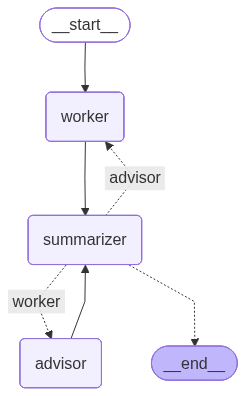

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
topic = "초보자를 타겟으로 한 투자 교육용 캐주얼 앱 개발을 위한 교육과정 설계 기반 컨텐츠 회의"
context = """
대분류-중분류-소분류-스테이지 구조로 교육 내용을 분류해야 한다.\n\n
스테이지는 5~10개 정도의 문제로, 5~15분 분량으로 구성된다.\n
소분류는 5~10개 정도의 스테이지들로 구성된다.\n\n
대분류는 경제, 금융 등과 같은 큰 분류이고,\n
중분류는 미시경제, 거시경제 등과 같은 분류이다.\n\n
이때 커리큘럼은 주제에 맞는 소분류들로 구성되고, 그 선후관계를 명시한 것을 말한다.\n
이 때 커리큘럼을 구성하는 소분류들은 다른 대분류, 중분류에 속한 것들이 모여있을 수 있다.\n\n
이 때, 대분류, 중분류, 소분류에 들어갈 컨텐츠를 구성하시오.
"""

In [19]:
config = {
    "configurable": {"thread_id": "test_session_1"},
    "recursion_limit": 8
}
initial_input = get_initial_state(agent_registry)
initial_input.update({
    "topic": topic, 
    "context":context
})

In [20]:
# 실행 및 결과 확인
for event in app.stream(initial_input, config=config):
    for node, value in event.items():
        print(f"\n[Node: {node}] 완료")
        if "task_history" in value:
            print(f"📖 장부 기록됨: {value['task_history'][-1]['output_summary']}")


[Node: worker] 완료

[Node: summarizer] 완료
📖 장부 기록됨: 훌륭한 작업자로서, 초보자를 타겟으로 한 투자 교육용 캐주얼 앱 개발을 위한 교육과정 설계 기반 컨텐츠 회의 내용을 아래와 같이 제안합니다. 주어진 대분류-중분류-소분류-스테이지 구조와 커리큘럼 선후관계 명시 요구사항을 충족하도록 구성했습니다.

---

## 초보자 투자 교육 앱 컨텐츠 커리큘럼 제안

**핵심 목표:** 투자를 처음 접하는 사용자들이 쉽고 재미있게 경제 및 투자 기초 지식을 습득하고, 건전한 투자 마인드를 형성하여 실제 투자에 자신감을 가질 수 있도록 돕는다.

**컨텐츠 구성 원칙:**
*   **쉬운 언어:** 전문 용어는 최소화하거나, 반드시 필요한 경우 초보자 눈높이에 맞춰 쉽게 설명한다.
*   **실생활 예시:** 일상생활과 관련된 예시를 풍부하게 활용하여 이해도를 높인다.
*   **단계별 학습:** 기초부터 심화로 점진적으로 난이도를 높여 학습 부담을 줄인다.
*   **흥미 유발:** 캐주얼 앱의 특성을 살려 퀴즈, 미션, 시뮬레이션 등 다양한 상호작용 요소를 고려한다.
*   **명확한 목표:** 각 스테이지와 소분류마다 학습 목표를 명확히 제시한다.

---

### 1. 대분류, 중분류, 소분류 컨텐츠 구성

#### **대분류 1: 경제와 자산관리의 첫걸음**
*   **설명:** 투자를 시작하기 전에 알아야 할 돈의 기본 원리, 개인 재무 관리의 중요성, 그리고 경제가 돌아가는 기초적인 방식을 이해합니다. 투자 이전에 탄탄한 재무 기반을 다지는 것이 목표입니다.

    *   **중분류 1.1: 개인 재무 관리의 기초**
        *   **설명:** 나의 돈을 제대로 파악하고 관리하는 방법을 배웁니다.
        *   **소분류 1.1.1: 소비와 저축 습관 만들기**
            *   **설명:** 올바른 소비 습관을 형성하고, 저축의 중요성과 효과적인 저축 방법을 알아봅니다.
           

GraphRecursionError: Recursion limit of 8 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT